# Relatório Final — Pipeline MLOps End-to-End
## Breast Cancer Wisconsin · scikit-learn → MLflow → FastAPI → Docker → Kubernetes

**Autor:** Fabio Estevam · **Data:** Julho/2026

Este notebook consolida todas as etapas do ciclo de vida do modelo:
1. Exploração e pré-processamento dos dados
2. Modelagem (baseline vs Random Forest)
3. Tuning de hiperparâmetros rastreado no MLflow
4. Monitoramento e simulação de data drift
5. Deploy: API FastAPI + Docker + Kubernetes (Docker Desktop)

Decisões arquiteturais estão registradas em `docs/adr/` (ADR-001 a ADR-004).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

from mlops_bc import config
from mlops_bc.data import load_raw, make_splits, quality_report

sns.set_theme(style="whitegrid", palette="deep")
mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)

## 1. Exploração dos Dados

O dataset tem 569 amostras e 30 features numéricas derivadas de imagens de
biópsia (raio, textura, perímetro, área etc., em três agregações: `mean`,
`error` e `worst`). **Convenção deste projeto: `target = 1` é maligno**
(classe positiva), invertendo o padrão do sklearn — assim, "recall" significa
diretamente "proporção de cânceres detectados" (ADR-004).

In [2]:
df = load_raw()
print(f"Shape: {df.shape}")
print(f"Malignos: {int(df.target.sum())} ({df.target.mean():.1%}) | "
      f"Benignos: {int((1 - df.target).sum())} ({1 - df.target.mean():.1%})")
df.describe().T.head(10)

Shape: (569, 31)
Malignos: 212 (37.3%) | Benignos: 357 (62.7%)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


### 1.1 Diagnóstico de qualidade
Completude, duplicatas, outliers (método IQR) e assimetria por feature.

In [3]:
qr = quality_report(df)
print(f"Duplicatas: {qr.attrs['n_duplicatas']}")
print(f"Completude mínima: {qr.completude_pct.min()}%")
qr.sort_values("outliers_iqr", ascending=False).head(10)

Duplicatas: 0
Completude mínima: 100.0%


,coluna,completude_pct,outliers_iqr,skewness
13,area error,100.0,65,5.447
10,radius error,100.0,38,3.089
12,perimeter error,100.0,38,3.444
23,worst area,100.0,35,1.859
14,smoothness error,100.0,30,2.314
15,compactness error,100.0,28,1.902
19,fractal dimension error,100.0,28,3.924
18,symmetry error,100.0,27,2.195
3,mean area,100.0,25,1.646
29,worst fractal dimension,100.0,24,1.663


**Leitura:** dataset limpo — zero nulos e zero duplicatas, então não há
imputação a fazer. Porém várias features de `area` e `error` têm forte
assimetria à direita e dezenas de outliers pelo critério IQR. Esses outliers
são biologicamente reais (tumores grandes), não erros de medição — por isso
**não são removidos**; o `StandardScaler` + Random Forest (invariante a
monotonicidade) lidam bem com eles.

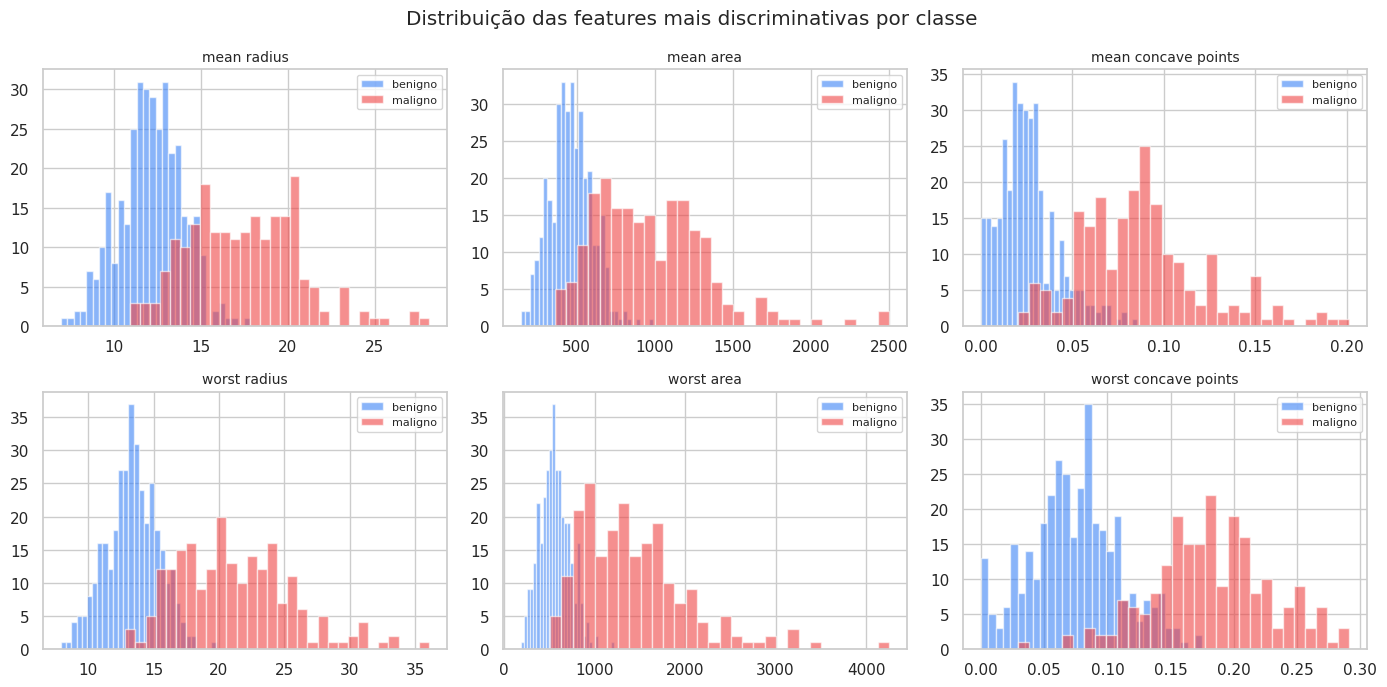

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
cols = ["mean radius", "mean area", "mean concave points",
        "worst radius", "worst area", "worst concave points"]
for ax, col in zip(axes.flat, cols):
    for label, name, color in [(0, "benigno", "#3b82f6"), (1, "maligno", "#ef4444")]:
        ax.hist(df.loc[df.target == label, col], bins=30, alpha=0.6,
                label=name, color=color)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Distribuição das features mais discriminativas por classe")
fig.tight_layout()
plt.show()

### 1.2 Correlação
As famílias `radius`/`perimeter`/`area` são quase colineares (r > 0.95) — o
que penalizaria modelos lineares sem regularização, mas é inofensivo para
Random Forest.

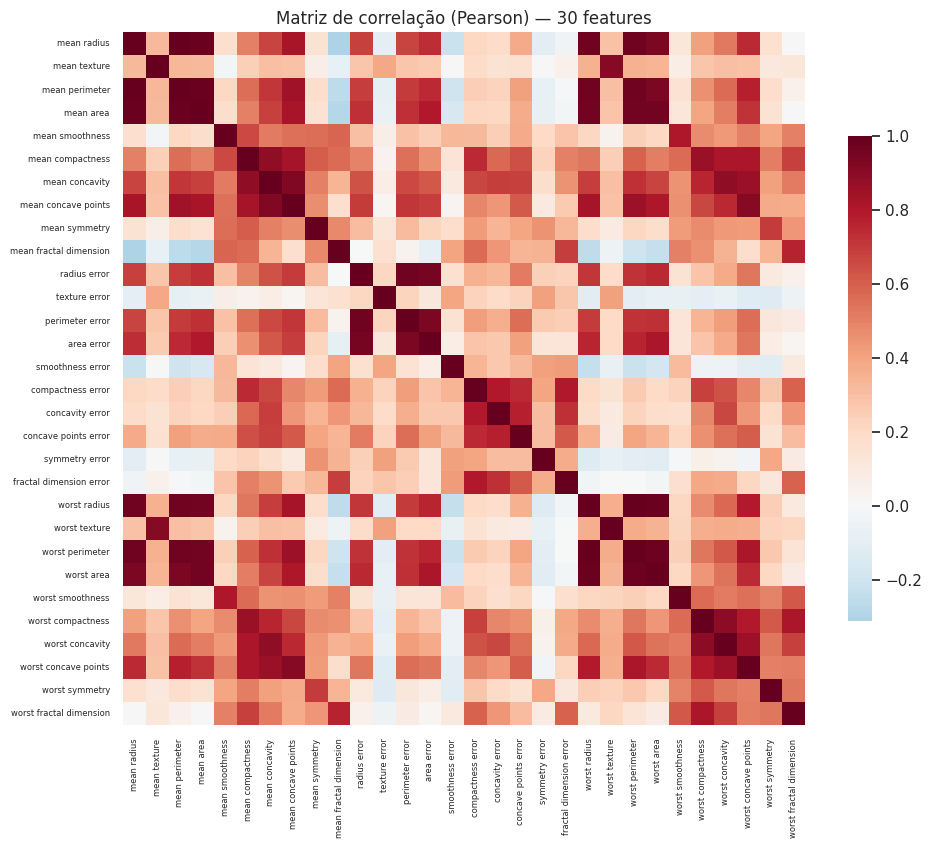

Features mais correlacionadas com o diagnóstico maligno:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
Name: target, dtype: float64


In [5]:
corr = df.drop(columns="target").corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=6)
ax.set_title("Matriz de correlação (Pearson) — 30 features")
plt.show()

top_target_corr = (
    df.corr()["target"].drop("target").abs().sort_values(ascending=False).head(8)
)
print("Features mais correlacionadas com o diagnóstico maligno:")
print(top_target_corr.round(3))

### 1.3 Pré-processamento
- **Split estratificado 80/20** (`random_state=42`) preservando a proporção
  de malignos (~37.4%) nos dois conjuntos.
- **Normalização via `StandardScaler` DENTRO do Pipeline sklearn** — o `fit`
  do scaler acontece só no treino (sem data leakage) e scaler + modelo viram
  um artefato único versionado (sem training-serving skew).
- Tratamento de nulos: não necessário (completude 100%).

In [6]:
x_train, x_test, y_train, y_test = make_splits(df)
print(f"Treino: {x_train.shape} | Teste: {x_test.shape}")
print(f"% maligno — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: (455, 30) | Teste: (114, 30)
% maligno — treino: 0.374 | teste: 0.368


## 2. Modelagem — Baseline vs Random Forest

Resultados dos runs registrados no MLflow (experimento `baseline-vs-rf`):

In [7]:
runs_base = mlflow.search_runs(experiment_names=[config.EXPERIMENT_BASELINE])
cols_m = [c for c in runs_base.columns if c.startswith("metrics.")]
tabela_base = (
    runs_base[["tags.mlflow.runName", *cols_m]]
    .rename(columns=lambda c: c.replace("metrics.", "").replace("tags.mlflow.runName", "modelo"))
    .round(4)
)
tabela_base

,modelo,roc_auc,precision,accuracy,recall,f1
0,random-forest-default,0.9929,1.000,0.9737,0.9286,0.9630
1,logreg-baseline,0.9960,0.975,0.9649,0.9286,0.9512


**Leitura:** a Regressão Logística é um baseline forte (o dataset é quase
linearmente separável — ROC-AUC 0.996). O Random Forest default empata em
recall e ganha em precision/accuracy. A pergunta que o tuning responde:
dá para extrair mais **recall** — a métrica que importa no domínio?

## 3. Tuning de Hiperparâmetros

Duas estratégias comparadas, ambas com `scoring="recall"` e CV estratificado
5-fold (experimento `hyperparameter-tuning`):
- **RandomizedSearchCV** — 40 amostras do espaço (5 hiperparâmetros)
- **HalvingGridSearchCV** — successive halving sobre grid reduzido
  (`min_resources=120` para garantir amostras positivas em todos os folds)

In [8]:
runs_tune = mlflow.search_runs(experiment_names=[config.EXPERIMENT_TUNING])
runs_tune = runs_tune[runs_tune["tags.mlflow.runName"].isin(
    ["randomized-search", "halving-grid-search"])].drop_duplicates(
    subset="tags.mlflow.runName", keep="first")
tabela_tune = runs_tune[[
    "tags.mlflow.runName", "metrics.cv_best_recall", "metrics.test_recall",
    "metrics.test_precision", "metrics.test_f1", "metrics.test_roc_auc",
    "metrics.search_time_s",
]].rename(columns=lambda c: c.replace("metrics.", "").replace(
    "tags.mlflow.runName", "estratégia")).round(4)
tabela_tune

,estratégia,cv_best_recall,test_recall,test_precision,test_f1,test_roc_auc,search_time_s
0,halving-grid-search,0.9538,0.9048,1.000,0.9500,0.9974,144.3759
1,randomized-search,0.9529,0.9286,0.975,0.9512,0.9970,69.6390


In [9]:
client = mlflow.MlflowClient()
mv = client.get_model_version_by_alias(config.REGISTERED_MODEL_NAME, config.CHAMPION_ALIAS)
print(f"Campeão no Model Registry: {config.REGISTERED_MODEL_NAME} "
      f"v{mv.version} @ alias '{config.CHAMPION_ALIAS}'")
run = client.get_run(mv.run_id)
print("Hiperparâmetros vencedores:")
for k, v in run.data.params.items():
    if k.startswith("model__"):
        print(f"  {k.removeprefix('model__')}: {v}")

Campeão no Model Registry: breast-cancer-classifier v2 @ alias 'champion'
Hiperparâmetros vencedores:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 4
  max_features: log2
  max_depth: None
  class_weight: balanced


**Análise honesta dos resultados:**
- Em **CV**, as duas buscas atingem recall ≈ 0.953 — acima do RF default.
- No **teste**, o RandomizedSearch venceu (recall 0.929, f1 0.951) e foi
  promovido a `champion`; o Halving foi ~2x mais lento neste grid pequeno
  (o ganho do successive halving aparece em espaços de busca maiores).
- O teste tem apenas 42 malignos: cada falso negativo custa ~2.4 p.p. de
  recall, então a diferença CV→teste é ruído amostral esperado.
- A meta de recall ≥ 0.95 do PRD **não foi atingida no threshold 0.5**.
  Caminho mapeado para v1.1: calibrar o threshold de decisão (baixá-lo
  aumenta recall ao custo de precision — trade-off aceitável pelo ADR-004).

## 4. Monitoramento e Data Drift

`drift.py` simula 6 "semanas" de produção aplicando shift gaussiano
progressivo às features e loga, por lote, as métricas do modelo + o
**PSI (Population Stability Index)** médio contra a distribuição de treino
(experimento `production-monitoring`). Limiar de alerta: PSI > 0.25.

In [10]:
drift_df = pd.read_csv(ROOT / "reports" / "drift_report.csv")
drift_df.round(3)

,semana,shift,psi_medio,accuracy,precision,recall,f1,roc_auc
0,1,0.00,0.075,0.974,1.000,0.929,0.963,0.998
1,2,0.10,0.109,0.974,0.953,0.976,0.965,0.997
2,3,0.25,0.398,0.939,0.857,1.000,0.923,0.999
3,4,0.50,1.592,0.789,0.636,1.000,0.778,0.994
4,5,0.75,2.995,0.623,0.494,1.000,0.661,0.978
5,6,1.00,4.463,0.491,0.420,1.000,0.592,0.904


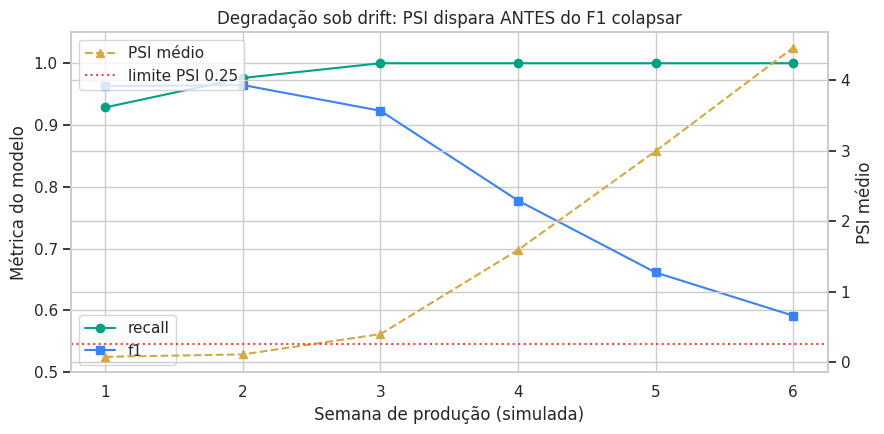

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(drift_df.semana, drift_df.recall, "o-", color="#00a086", label="recall")
ax1.plot(drift_df.semana, drift_df.f1, "s-", color="#3b82f6", label="f1")
ax1.set_xlabel("Semana de produção (simulada)")
ax1.set_ylabel("Métrica do modelo")
ax1.set_ylim(0.5, 1.05)
ax1.legend(loc="lower left")
ax2 = ax1.twinx()
ax2.plot(drift_df.semana, drift_df.psi_medio, "^--", color="#d4a843", label="PSI médio")
ax2.axhline(0.25, color="#ef4444", ls=":", label="limite PSI 0.25")
ax2.set_ylabel("PSI médio")
ax2.legend(loc="upper left")
ax1.set_title("Degradação sob drift: PSI dispara ANTES do F1 colapsar")
fig.tight_layout()
plt.show()

**Leitura (o insight central de monitoramento):** a partir da semana 3 o PSI
cruza o limiar (0.398) enquanto o F1 ainda parece aceitável (0.923). Nas
semanas seguintes o F1 despenca até 0.592. O recall vai a 1.0 não por mérito:
com o shift positivo, o modelo passa a classificar quase tudo como maligno —
a precision é quem colapsa. **Moral:** monitorar só a métrica-alvo esconde o
problema; o PSI é o alarme antecipado que dispara o retraining (em produção,
esse gatilho acionaria o pipeline de re-treino via CI/CD).

## 5. Deploy — API, Docker e Kubernetes

### 5.1 API FastAPI (`api/main.py`)
- `POST /predict`: valida as 30 features via Pydantic (tipo, presença,
  `>= 0`; payload extra é rejeitado) e responde classe, probabilidade,
  versão do modelo e latência (~6 ms medidos localmente).
- `GET /health`: usado pelas probes do Kubernetes.
- O modelo vem de `models/model.joblib` (exportado pelo `tune.py` a partir
  do champion do Registry) — **runtime independente do MLflow server**.

Smoke test executado com casos reais do dataset:
```json
// caso maligno real  -> {"prediction": 1, "diagnosis": "maligno", "probability_malignant": 0.866}
// caso benigno real  -> {"prediction": 0, "diagnosis": "benigno", "probability_malignant": 0.055}
```

### 5.2 Docker (`Dockerfile`)
Build multi-stage: estágio 1 instala dependências mínimas
(`requirements-api.txt`) em venv; estágio 2 (`python:3.12-slim`) copia venv +
código + modelo, roda como usuário não-root e define `HEALTHCHECK`.
```bash
make docker-build   # docker build -t breast-cancer-api:1.0.0 .
make docker-run     # docker run --rm -p 8000:8000 breast-cancer-api:1.0.0
curl localhost:8000/health
```

### 5.3 Kubernetes (`k8s/`)
- `deployment.yaml`: **2 réplicas**, `RollingUpdate` com `maxUnavailable: 0`
  (zero-downtime), requests/limits de CPU e memória, probes de readiness
  (pod só recebe tráfego com modelo carregado) e liveness.
- `service.yaml`: `type: LoadBalancer` — no Docker Desktop é provisionado
  automaticamente em `localhost:8000` (ADR-003; fallback: NodePort).
```bash
kubectl apply -f k8s/
kubectl get pods -l app=breast-cancer-api      # 2/2 Running
kubectl get svc breast-cancer-api              # EXTERNAL-IP: localhost
curl localhost:8000/health

# Teste de escalabilidade e resiliência:
kubectl scale deployment breast-cancer-api --replicas=4
kubectl delete pod <um-dos-pods>               # K8s recria sozinho
kubectl rollout status deployment/breast-cancer-api
```

## 6. Conclusão

| Etapa | Evidência |
|---|---|
| Dados → pré-processamento → modelo | Split estratificado + Pipeline (scaler+modelo) sem leakage |
| HPO integrado ao MLflow | 2 estratégias comparadas; champion v2 no Model Registry |
| Monitoramento de métricas | PSI + métricas por lote no experimento `production-monitoring` |
| Deploy escalável | Imagem multi-stage + Deployment 2 réplicas com probes e rolling update |

**Qualidade de engenharia:** 16 testes (97.7% de cobertura), Ruff limpo,
CI GitHub Actions com lint, testes, Bandit e smoke test do container.

**Próximos passos (v1.1):** calibração de threshold para recall ≥ 0.95,
retraining automático disparado por PSI, e HPA (Horizontal Pod Autoscaler)
no lugar do scale manual.